In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [55]:
no2 = pd.read_csv("./data/NO2_manual_1213m.csv")
wind_u = pd.read_csv("./data/WIND_U_manual_27929m.csv")
wind_v = pd.read_csv("./data/WIND_V_manual_27929m.csv")
temp = pd.read_csv("./data/TEMP_manual_27929m.csv")
co = pd.read_csv("./data/CO_manual_1213m.csv")



This is the code I used to fetch the elevation data for each of the lat longs and add them to the no2 dataset

In [5]:
import requests


def fetch_elevations(batch, session):
    url = "https://api.open-elevation.com/api/v1/lookup"
    payload = {
        "locations": [
            {"latitude": latitude, "longitude": longitude} for latitude, longitude in batch
        ]
    }
    response = session.post(url, json=payload, timeout=60)
    response.raise_for_status()
    return response.json()["results"]


if "elevation" not in no2.columns:
    no2["elevation"] = np.nan

existing_elevation_lookup = (
    no2.loc[no2["elevation"].notna(), ["latitude", "longitude", "elevation"]]
    .drop_duplicates(subset=["latitude", "longitude"])
    .set_index(["latitude", "longitude"])["elevation"]
    .to_dict()
)

unique_coordinates = no2.loc[
    ~no2.set_index(["latitude", "longitude"]).index.isin(existing_elevation_lookup.keys()),
    ["latitude", "longitude"],
].drop_duplicates().copy()

session = requests.Session()
elevation_lookup = dict(existing_elevation_lookup)
batch_size = 500

for start in range(0, len(unique_coordinates), batch_size):
    batch_frame = unique_coordinates.iloc[start:start + batch_size][["latitude", "longitude"]]
    batch = list(batch_frame.itertuples(index=False, name=None))
    try:
        results = fetch_elevations(batch, session)
        for (latitude, longitude), result in zip(batch, results):
            elevation_lookup[(latitude, longitude)] = result["elevation"]
    except requests.RequestException as exc:
        print(f"Elevation lookup failed for batch starting at row {start}: {exc}")
        for latitude, longitude in batch:
            elevation_lookup[(latitude, longitude)] = np.nan

    no2["elevation"] = [
        elevation_lookup.get((latitude, longitude), np.nan)
        for latitude, longitude in no2[["latitude", "longitude"]].itertuples(index=False, name=None)
    ]
    no2.to_csv("./data/NO2_manual_1213m.csv", index=False)

    print(f"Processed batch {start // batch_size + 1} / {(len(unique_coordinates) + batch_size - 1) // batch_size} and checkpointed ./data/NO2_manual_1213m.csv.")
    print(no2[["latitude", "longitude", "elevation"]].head())

print(f"Filled elevation for {len(unique_coordinates)} previously missing unique latitude/longitude pairs.")

Filled elevation for 0 previously missing unique latitude/longitude pairs.


In [3]:
def _get_station_grid_lookup(weather_df):
    cache_key = "_station_grid_lookup"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    station_latitudes = np.sort(weather_df["latitude"].dropna().unique())
    station_longitudes = np.sort(weather_df["longitude"].dropna().unique())

    if len(station_latitudes) == 0 or len(station_longitudes) == 0:
        raise ValueError("weather_df must contain at least one valid latitude and longitude.")

    lat_bounds = np.concatenate(([-np.inf], (station_latitudes[:-1] + station_latitudes[1:]) / 2, [np.inf]))
    lon_bounds = np.concatenate(([-np.inf], (station_longitudes[:-1] + station_longitudes[1:]) / 2, [np.inf]))

    cached = (station_latitudes, station_longitudes, lat_bounds, lon_bounds)
    weather_df.attrs[cache_key] = cached
    return cached


def _nearest_station_coordinate(value, station_values, bounds):
    station_index = np.searchsorted(bounds, value, side="right") - 1
    station_index = int(np.clip(station_index, 0, len(station_values) - 1))
    return station_values[station_index]


def _get_daily_station_cache(weather_df, col):
    cache_key = f"_daily_station_cache::{col}"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    timestamps = weather_df.attrs.get("_timestamp_cache")
    if timestamps is None or len(timestamps) != len(weather_df):
        timestamps = pd.to_datetime(weather_df["timestamp"], errors="coerce")
        weather_df.attrs["_timestamp_cache"] = timestamps

    valid_rows = timestamps.notna() & weather_df[col].notna() & weather_df["latitude"].notna() & weather_df["longitude"].notna()
    daily_station_cache = {}

    if valid_rows.any():
        day_values = timestamps.loc[valid_rows].dt.normalize()
        valid_frame = weather_df.loc[valid_rows, ["latitude", "longitude", col]].copy()
        valid_frame["day"] = day_values.values
        grouped = (
            valid_frame.groupby(["day", "latitude", "longitude"], as_index=False)[col]
            .mean()
        )

        for day, day_frame in grouped.groupby("day", sort=False):
            daily_station_cache[pd.Timestamp(day)] = day_frame.set_index(["latitude", "longitude"])[col].to_dict()

    weather_df.attrs[cache_key] = daily_station_cache
    return daily_station_cache


def get_avg_weather_for_closest_latlong(latitude, longitude, date, weather_df, col):
    date = pd.to_datetime(date)
    day_start = date.normalize()

    if "timestamp" not in weather_df.columns:
        raise KeyError("weather_df must contain a 'timestamp' column.")
    if col not in weather_df.columns:
        raise KeyError(f"{col} not found in weather_df columns.")

    station_latitudes, station_longitudes, lat_bounds, lon_bounds = _get_station_grid_lookup(weather_df)
    closest_latitude = _nearest_station_coordinate(latitude, station_latitudes, lat_bounds)
    closest_longitude = _nearest_station_coordinate(longitude, station_longitudes, lon_bounds)

    daily_station_cache = _get_daily_station_cache(weather_df, col)
    day_values = daily_station_cache.get(day_start)

    if day_values is None:
        raise ValueError(f"No weather data found for date {day_start.date()}.")

    station_value = day_values.get((closest_latitude, closest_longitude))
    if station_value is not None and not pd.isna(station_value):
        return station_value

    day_mask = pd.to_datetime(weather_df["timestamp"], errors="coerce").dt.normalize().eq(day_start)
    daily_weather = weather_df.loc[day_mask, ["latitude", "longitude", col]].dropna(subset=[col])
    if daily_weather.empty:
        raise ValueError(f"No usable weather values found for date {day_start.date()}.")

    distance = (daily_weather[["latitude", "longitude"]] - [latitude, longitude]).abs().sum(axis=1)
    closest_idx = distance.idxmin()
    return daily_weather.loc[closest_idx, col]


wind_u["timestamp"] = pd.to_datetime(wind_u["timestamp"], errors="coerce")
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
# 28.219475044486515,77.1511982864422,192.0,2019-01-09
print(get_avg_weather_for_closest_latlong(29.219475044486515, 79.2011985864423, "2019-01-09", temp, "TEMP"))


286.45952916666664


Below is the code I used to visualize how the temperature stations are located across my ROI, and what latlongs i have no2 data for (from a random days image)(also shows missingness on that day, but that is an aside)

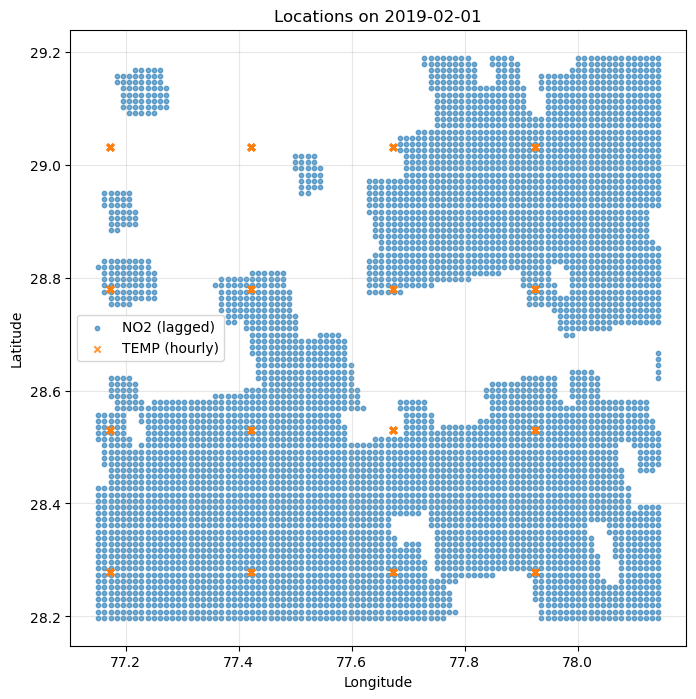

In [7]:
# plot lat/lon points from no2_lagged_df and temp for a single day
selected_day = pd.to_datetime("2019-02-01").normalize()

# ensure temp timestamps are datetimes
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
temp_day = temp[temp["timestamp"].dt.normalize() == selected_day]

no2_day = no2[pd.to_datetime(no2["timestamp"]).dt.normalize() == selected_day]

plt.figure(figsize=(8, 8))
plt.scatter(no2_day["longitude"], no2_day["latitude"], s=10, c="C0", alpha=0.6, label="NO2 (lagged)")
plt.scatter(temp_day["longitude"], temp_day["latitude"], s=20, c="C1", marker="x", alpha=0.8, label="TEMP (hourly)")
plt.title(f"Locations on {selected_day.date()}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.3)
plt.show()

# Section 1: Data preprocessing 

first we establish the lagged dataset, which involves creating new features based on previous time steps of the data. For example, if we have a time series, we can create lagged features such as the n02 at time t-1, t-2, etc. This hopefully will allow us to capture the temporal dependencies in the data.

Now, we create the lagged dataset. We will add the no2 values from the previous 7 days and the elevation and temperature values of current day as features to predict the no2 value of the next day.

In [ ]:
# adding nearest temp reading to the dataset

from tqdm.auto import tqdm

date_column = "timestamp"

no2[date_column] = pd.to_datetime(no2[date_column], errors="coerce")
no2 = no2.dropna(subset=[date_column]).copy()
no2["day"] = no2[date_column].dt.normalize()

value_column = "NO2"
# Compute TEMP once per unique (latitude, longitude, day) and merge it back into no2.
unique_day_locs = no2[["latitude", "longitude", "day"]].drop_duplicates().reset_index(drop=True)

temps = []
for lat, lon, day in tqdm(
    unique_day_locs.itertuples(index=False, name=None),
    total=len(unique_day_locs),
    desc="Computing TEMP for unique (lat,lon,day)",
):
    try:
        val = get_avg_weather_for_closest_latlong(lat, lon, day, temp, "TEMP")
    except Exception:
        val = np.nan
    temps.append(val)

unique_day_locs["TEMP"] = temps
no2 = no2.merge(unique_day_locs, on=["latitude", "longitude", "day"], how="left")

print(f"Attached TEMP to no2 for {len(unique_day_locs)} unique (lat, lon, day) rows.")
no2[["latitude", "longitude", "day", "TEMP"]].head()

Computing TEMP for unique (lat,lon,day):   0%|          | 0/2056978 [00:00<?, ?it/s]

Attached TEMP to no2 for 2056978 unique (lat, lon, day) rows.


,latitude,longitude,day,TEMP
0,28.197678,77.151198,2019-01-01,287.244276
1,28.197678,77.162097,2019-01-01,287.244276
2,28.197678,77.172995,2019-01-01,287.244276
3,28.197678,77.183893,2019-01-01,287.244276
4,28.197678,77.194792,2019-01-01,287.244276


In [53]:
daily_no2 = (
    no2.groupby(["latitude", "longitude", "timestamp"], as_index=False)
    .agg(
        no2=("NO2", "mean"),
        TEMP=("TEMP", "mean"),
    )
)

if "elevation" in no2.columns:
    elevation_by_location = (
        no2[["latitude", "longitude", "elevation"]]
        .dropna(subset=["latitude", "longitude"])
        .drop_duplicates(subset=["latitude", "longitude"])
    )
    daily_no2 = daily_no2.merge(elevation_by_location, on=["latitude", "longitude"], how="left")
else:
    daily_no2["elevation"] = np.nan

daily_no2 = daily_no2.sort_values(["latitude", "longitude", "day"]).reset_index(drop=True)

lag_columns = []
for lag in range(0, 8):
    column_name = f"no2_day{lag}"
    daily_no2[column_name] = daily_no2.groupby(["latitude", "longitude"])["no2"].shift(lag)
    lag_columns.append(column_name)

no2_lagged_df = daily_no2.rename(columns={"day": "datetime"})[
    ["latitude", "longitude", "elevation", "datetime", "TEMP"] + lag_columns
].dropna(subset=lag_columns).reset_index(drop=True)

print(f"Created lagged NO2 dataset with shape: {no2_lagged_df.shape}")
no2_lagged_df.head()

KeyError: "Column(s) ['TEMP'] do not exist"

In [51]:
no2_lagged_df = no2_lagged_df.sort_values(["datetime", "latitude", "longitude"]).reset_index(drop=True)


NameError: name 'no2_lagged_df' is not defined

In [ ]:
# no2_lagged_df.to_csv("./data/no2_lagged.csv", index=False)

below is code to visualise monthly heatmaps of the no2 data

In [50]:
def monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-02-01")):
    # Validate column
    if plot_col not in no2_lagged_df.columns:
        raise KeyError(f"{plot_col} not found in no2_lagged_df columns.")

    # Ensure datetime is normalized (date-only) for reliable filtering
    no2_lagged_df["datetime"] = pd.to_datetime(no2_lagged_df["datetime"]).dt.normalize()

    # If selected date is outside available range, snap to nearest available date
    available_dates = no2_lagged_df["datetime"].dropna().sort_values().unique()
    if len(available_dates) == 0:
        raise ValueError("no2_lagged_df has no valid datetime values.")

    nearest_datetime = min(available_dates, key=lambda d: abs(d - selected_datetime.to_datetime64()))
    nearest_datetime = pd.to_datetime(nearest_datetime)

    # Build month window from nearest date (fixes empty month issue like 2020-01 for 2019-only data)
    month_start = nearest_datetime.to_period("M").to_timestamp()
    month_end = month_start + pd.offsets.MonthEnd(1)
    all_days = pd.date_range(month_start, month_end, freq="D")

    # Data for this month
    month_df = no2_lagged_df[
        (no2_lagged_df["datetime"] >= month_start) &
        (no2_lagged_df["datetime"] <= month_end)
    ].copy()

    if month_df.empty:
        raise ValueError(f"No data found for month {month_start.strftime('%Y-%m')}.")

    # Shared color scale
    vmin = month_df[plot_col].min()
    vmax = month_df[plot_col].max()
    if pd.isna(vmin) or pd.isna(vmax):
        raise ValueError(f"{plot_col} is all-NaN in {month_start.strftime('%Y-%m')}.")

    # Grid layout
    n_days = len(all_days)
    ncols = 7
    nrows = int(np.ceil(n_days / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    last_mesh = None

    for i, day in enumerate(all_days):
        ax = axes[i]
        day_df = month_df[month_df["datetime"] == day]

        if day_df.empty:
            ax.set_title(f"{day.date()}\n(no data)", fontsize=9)
            ax.axis("off")
            continue

        heatmap_df = day_df.pivot_table(
            index="latitude",
            columns="longitude",
            values=plot_col,
            aggfunc="mean"
        ).sort_index().sort_index(axis=1)

        if heatmap_df.empty or np.all(np.isnan(heatmap_df.values)):
            ax.set_title(f"{day.date()}\n(no valid values)", fontsize=9)
            ax.axis("off")
            continue

        lon_grid, lat_grid = np.meshgrid(heatmap_df.columns.values, heatmap_df.index.values)
        last_mesh = ax.pcolormesh(
            lon_grid, lat_grid, heatmap_df.values,
            shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
        )

        ax.set_title(str(day.date()), fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide extra axes
    for j in range(n_days, len(axes)):
        axes[j].axis("off")

    # Shared colorbar
    if last_mesh is not None:
        fig.colorbar(last_mesh, ax=axes.tolist(), shrink=0.85, label=plot_col)

    fig.suptitle(f"Daily {plot_col} Heatmaps - {month_start.strftime('%B %Y')}", fontsize=14)
    plt.show()


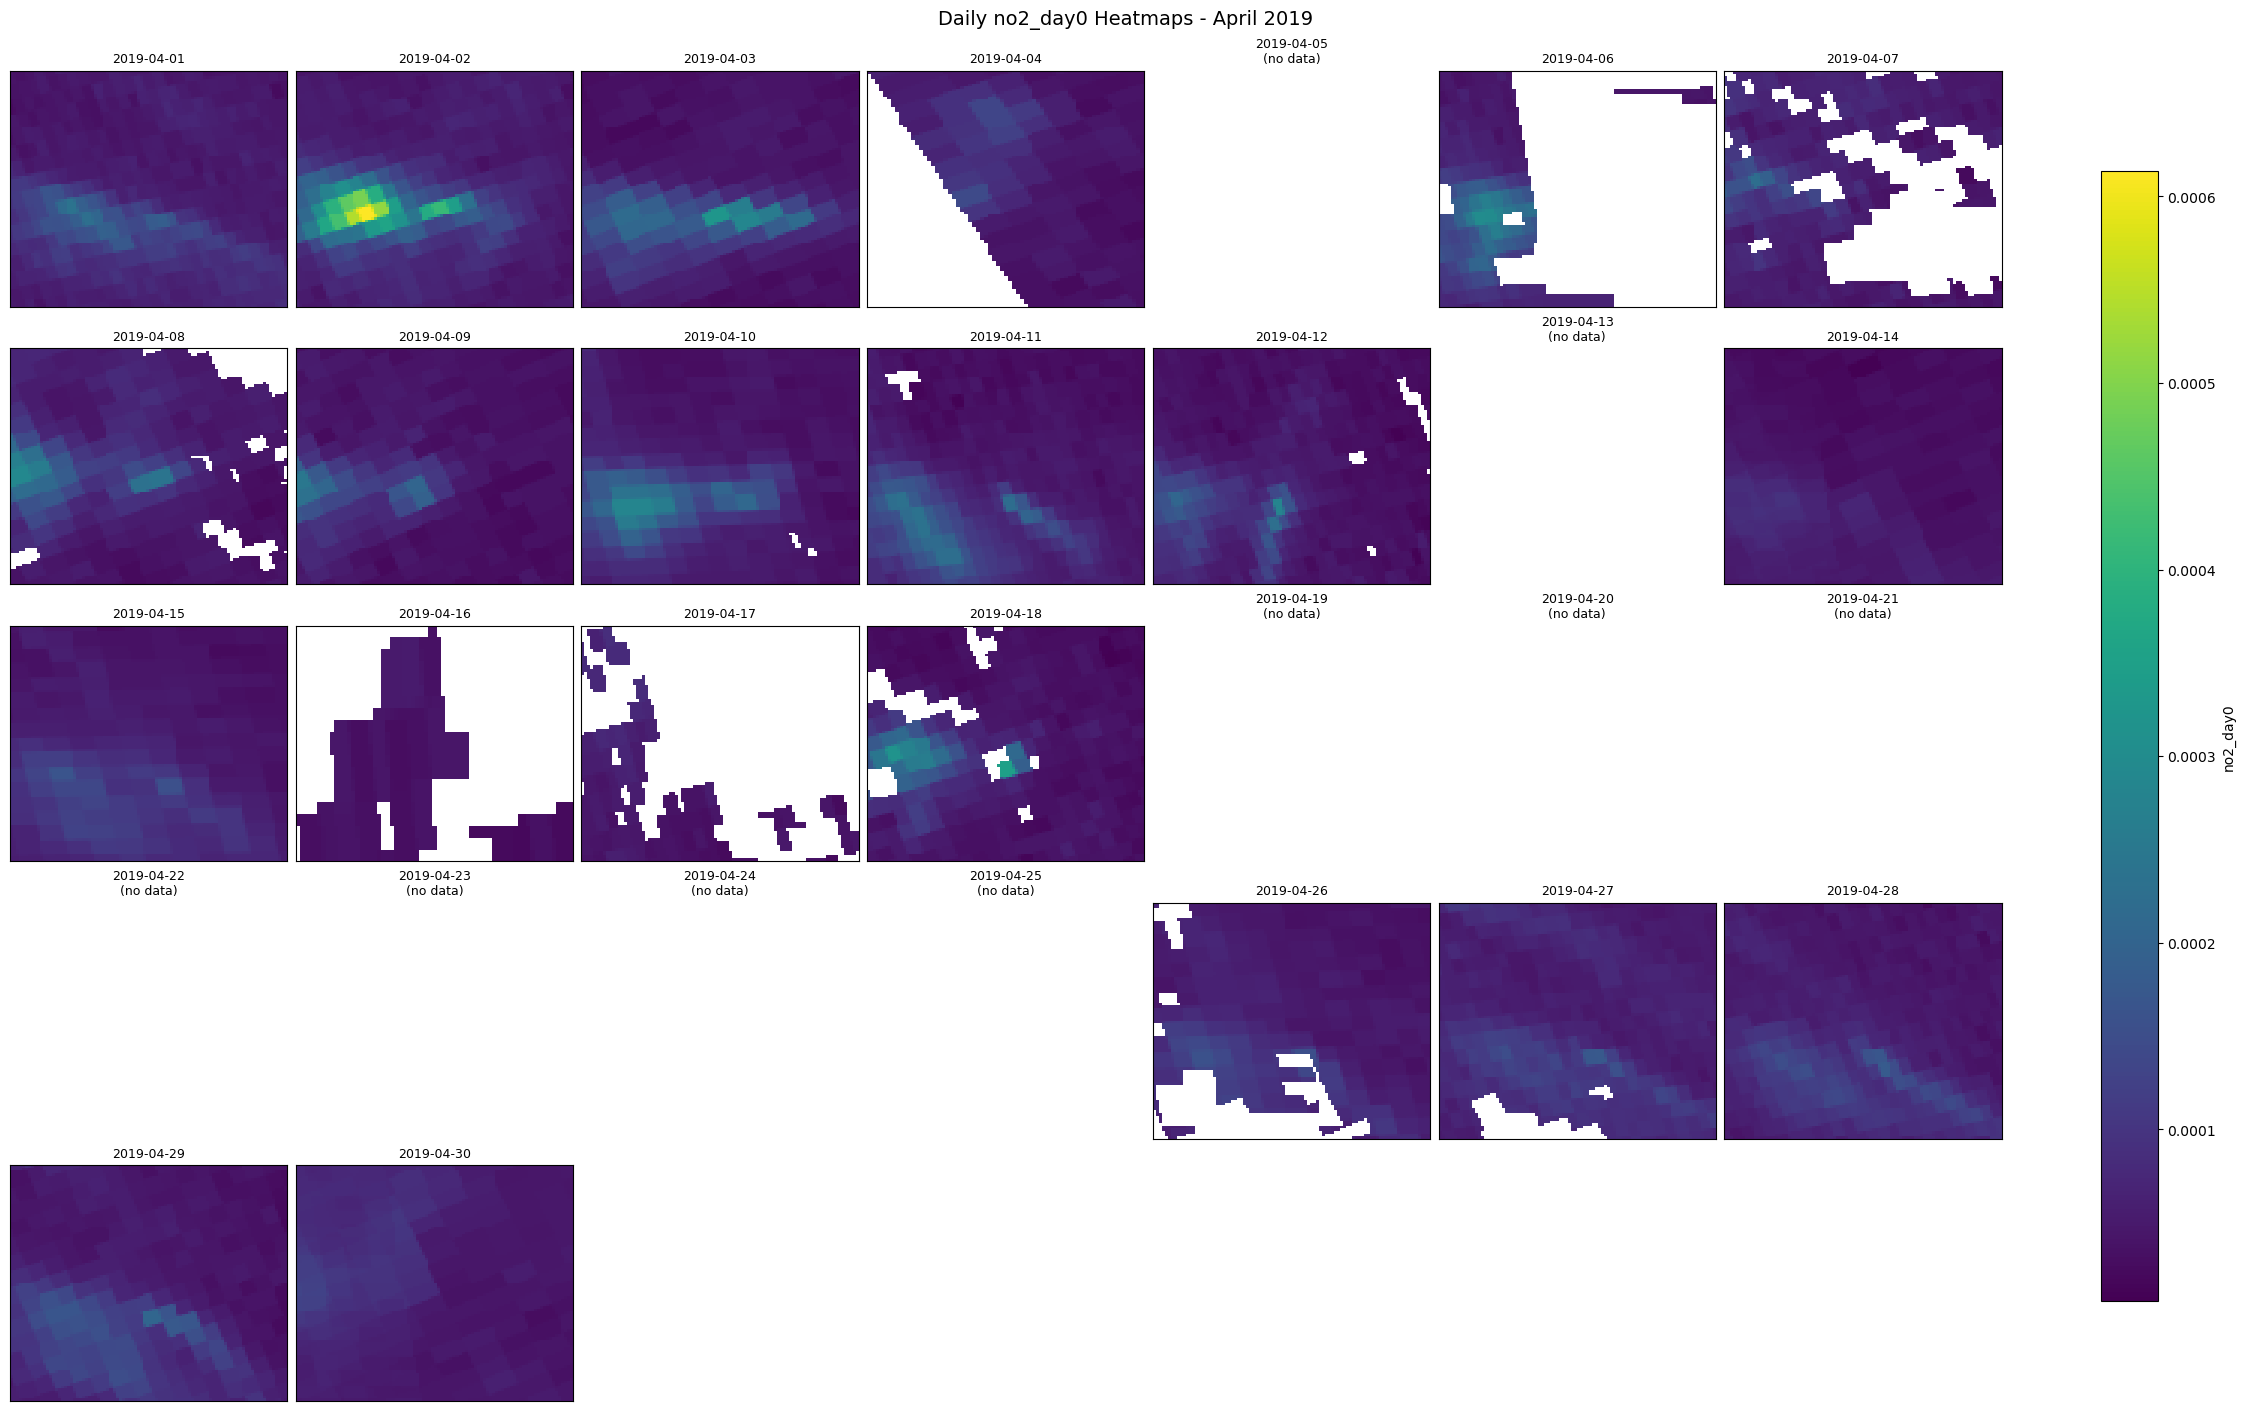

In [51]:
monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-04-01"))

Checklist for next steps:
* Build daily 2D grids from the tuples
* Use last 7 days to predict next day
* Try:
    - ~~persistence baseline~~
    - ~~XGBoost on lagged features~~
    - ConvLSTM or CNN on stacked grids
* Add mask + time features
* move to graph models if needed

# persistence baseline 

Persistence baseline for NO2
Train rows: 1,357,071
Test rows:  369,351
Time split:  2019-10-24 to 2019-12-31
MAE:  0.0000
RMSE: 0.0001
R^2:  0.1442
NMAE: 0.4573


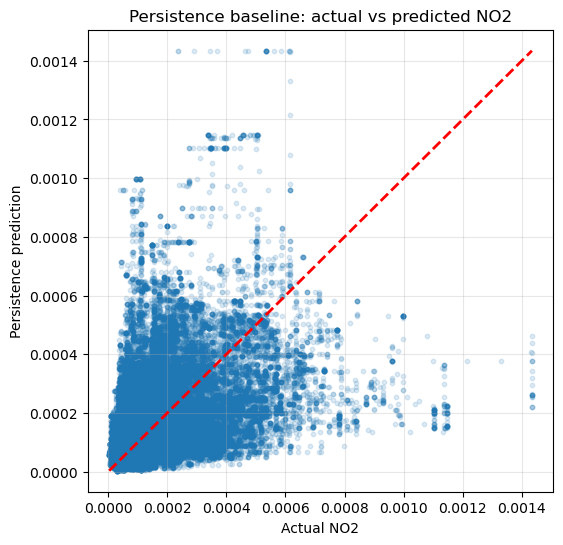

,datetime,latitude,longitude,no2_true,no2_persistence_pred
1357071,2019-10-24,28.862476,77.489046,0.000043,0.000052
1357072,2019-10-24,28.862476,77.499944,0.000043,0.000054
1357073,2019-10-24,28.862476,77.478148,0.000043,0.000049
1357074,2019-10-24,28.862476,77.510843,0.000043,0.000054
1357075,2019-10-24,28.862476,77.303775,0.000048,0.000056


In [ ]:
# Persistence baseline for NO2
# Idea: for each pixel-day, predict today's NO2 using yesterday's NO2.
# This is a strong sanity-check baseline before trying any neural network.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Choose the target and the persistence feature.
# In this lagged table:
# - no2_day0 = today's NO2 (the thing we want to predict)
# - no2_day1 = yesterday's NO2 (the persistence forecast)
target_col = "no2_day0"
pred_col = "no2_day1"

# 2) Keep only rows where both target and persistence input exist.
baseline_df = no2_lagged_df[["datetime", "latitude", "longitude", target_col, pred_col]].dropna().copy()
baseline_df = baseline_df.sort_values("datetime").reset_index(drop=True)

# 3) Make a time-based split so we evaluate on future dates, not shuffled rows.
unique_dates = baseline_df["datetime"].drop_duplicates().sort_values().to_list()
cutoff_index = max(1, int(len(unique_dates) * 0.8))
train_dates = set(unique_dates[:cutoff_index])
test_dates = set(unique_dates[cutoff_index:])

train_df = baseline_df[baseline_df["datetime"].isin(train_dates)].copy()
test_df = baseline_df[baseline_df["datetime"].isin(test_dates)].copy()

# 4) Evaluate the baseline on the held-out future period.
y_true = test_df[target_col].to_numpy()
y_pred = test_df[pred_col].to_numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# A simple normalized error helps when NO2 values vary a lot across pixels.
mean_abs_target = np.mean(np.abs(y_true))
nmae = mae / mean_abs_target if mean_abs_target != 0 else np.nan

print("Persistence baseline for NO2")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Time split:  {min(test_df['datetime']).date()} to {max(test_df['datetime']).date()}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")
print(f"NMAE: {nmae:.4f}")

# # 5) Save predictions so you can inspect where persistence works well or fails.
# baseline_predictions = test_df[["datetime", "latitude", "longitude", target_col, pred_col]].rename(
#     columns={target_col: "no2_true", pred_col: "no2_persistence_pred"}
# )

# 6) Quick diagnostic plot: actual vs predicted.
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.15, s=10)
min_val = min(np.min(y_true), np.min(y_pred))
max_val = max(np.max(y_true), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.xlabel("Actual NO2")
plt.ylabel("Persistence prediction")
plt.title("Persistence baseline: actual vs predicted NO2")
plt.grid(True, alpha=0.3)
plt.show()

# baseline_predictions.head()

# XGBoost 

We will use latitude, longitude, elevation, temperature, and the seven lagged NO2 values as features to predict `no2_day0`. The `datetime` column is only used to keep the train/test split chronological.

In [6]:
no2_lagged_df = pd.read_csv("./data/no2_lagged.csv")

In [7]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
# Step 1: prepare the lagged dataframe for modeling
no2_lagged_df = no2_lagged_df.copy()
no2_lagged_df["datetime"] = pd.to_datetime(no2_lagged_df["datetime"])
no2_lagged_df = no2_lagged_df.sort_values(["datetime", "latitude", "longitude"]).reset_index(drop=True)

# Step 2: define the features and the target
feature_cols = ["latitude", "longitude", "elevation", "TEMP"] + [f"no2_day{i}" for i in range(1,8)]
target_col = "no2_day0"

X = no2_lagged_df[feature_cols]
y = no2_lagged_df[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Features used:", feature_cols)

# Step 3: split chronologically to avoid leaking future information into training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

# Step 4: train an XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=32746,
    n_jobs=-1,
    tree_method="exact",
)


Feature matrix shape: (1726422, 11)
Target vector shape: (1726422,)
Features used: ['latitude', 'longitude', 'elevation', 'TEMP', 'no2_day1', 'no2_day2', 'no2_day3', 'no2_day4', 'no2_day5', 'no2_day6', 'no2_day7']
Train rows: 1,381,137
Test rows: 345,285


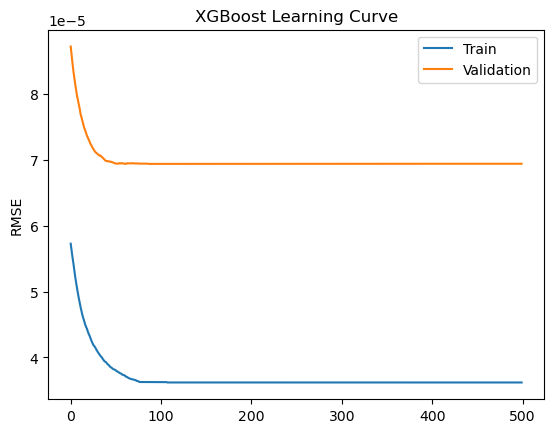

In [27]:
eval_set = [(X_train, y_train), (X_test, y_test)]
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 2. Extract and Plot
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
plt.legend()
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.show()

In [28]:
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2: {r2:.4f}")

# Step 6: inspect which features the model relied on most
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

importance_df

MAE: 0.000035
RMSE: 0.000000
R^2: 0.3408


,feature,importance
4,no2_day1,0.403953
8,no2_day5,0.098219
5,no2_day2,0.089851
0,latitude,0.060094
3,TEMP,0.059577
6,no2_day3,0.057747
7,no2_day4,0.051686
9,no2_day6,0.051599
1,longitude,0.049940
10,no2_day7,0.043446


# Deep Learning:

Now we try the following architectures:
* CNN 
* ConvLSTM 
* Unet encoder-decoder
* 3D CNN

# CNN
We try to make a simple CNN architecture that takes in a radius-interpolated 2D grid of NO2 values and predicts the next day's NO2 values. We will stack the last 7 days of NO2 values as input channels to the CNN.

The problem here is that the satellite data is not on a regular grid, and it has many missing values. Instead of nearest-neighbor filling, we use radius-based inverse-distance weighting on a regular grid whose radius depends on the chosen grid size. Cells without local support stay masked, which keeps the missingness explicit for the CNN.
First, we identify the grid size we want to test, build a regular latitude/longitude lattice for each day, and interpolate the NO2 values within a radius tied to that grid spacing.

In [56]:
coords = no2[["latitude", "longitude"]].dropna().drop_duplicates().sort_values(["latitude", "longitude"])
lat_vals = np.sort(coords["latitude"].unique())
lon_vals = np.sort(coords["longitude"].unique())
lat_diffs = pd.Series(lat_vals).diff().dropna()
lon_diffs = pd.Series(lon_vals).diff().dropna()

print(f"Unique NO2 coordinates: {len(coords):,}")
print(f"Unique latitude values: {len(lat_vals):,}")
print(f"Unique longitude values: {len(lon_vals):,}")
print(f"Dense grid size from unique lat/lon axes: {len(lat_vals):,} x {len(lon_vals):,} = {len(lat_vals) * len(lon_vals):,} cells")
print(f"Latitude range: {lat_vals.min():.6f} to {lat_vals.max():.6f}")
print(f"Longitude range: {lon_vals.min():.6f} to {lon_vals.max():.6f}")
print(f"Typical latitude spacing: {lat_diffs.mode().iloc[0]:.6f}")
print(f"Typical longitude spacing: {lon_diffs.mode().iloc[0]:.6f}")

# Build a regular grid using the unique axis values.
# This preserves the dataset's native spatial resolution instead of inventing a new one.
no2_grid_shape = (len(lat_vals), len(lon_vals))
print(f"Recommended CNN grid shape for this dataset: {no2_grid_shape[0]} rows x {no2_grid_shape[1]} columns")

Unique NO2 coordinates: 64,579
Unique latitude values: 276
Unique longitude values: 551
Dense grid size from unique lat/lon axes: 276 x 551 = 152,076 cells
Latitude range: 28.197678 to 29.194199
Longitude range: 77.151198 to 78.147961
Typical latitude spacing: 0.006124
Typical longitude spacing: 0.001591
Recommended CNN grid shape for this dataset: 276 rows x 551 columns


In [57]:
from scipy.spatial import cKDTree

lat_vals = np.sort(no2["latitude"].dropna().unique())
lon_vals = np.sort(no2["longitude"].dropna().unique())

print(f"Regular grid from all NO2 coordinates: {len(lat_vals)} x {len(lon_vals)}")
print(f"Occupancy in the full lat/lon rectangle: {no2[['latitude', 'longitude']].dropna().drop_duplicates().shape[0] / (len(lat_vals) * len(lon_vals)):.3%}")


def _grid_axes_for_shape(source_df, grid_shape=None):
    if grid_shape is None:
        return lat_vals, lon_vals

    lat_axis = np.linspace(source_df["latitude"].min(), source_df["latitude"].max(), grid_shape[0])
    lon_axis = np.linspace(source_df["longitude"].min(), source_df["longitude"].max(), grid_shape[1])
    return lat_axis, lon_axis


def _radius_for_axes(lat_axis, lon_axis, radius_multiplier=1.5):
    if len(lat_axis) < 2 or len(lon_axis) < 2:
        return 0.0

    lat_step = float(np.median(np.diff(lat_axis)))
    lon_step = float(np.median(np.diff(lon_axis)))
    return radius_multiplier * float(np.hypot(lat_step, lon_step))


def build_radius_regular_grid(day_frame, grid_shape=None, value_col="NO2", radius_multiplier=1.5, power=2.0):
    """Convert scattered lat/lon observations into a regular grid using radius-based IDW."""
    lat_axis, lon_axis = _grid_axes_for_shape(no2, grid_shape)
    grid = np.full((len(lat_axis), len(lon_axis)), np.nan, dtype=np.float32)
    mask = np.zeros((len(lat_axis), len(lon_axis)), dtype=np.uint8)

    clean_frame = day_frame.dropna(subset=["latitude", "longitude", value_col]).copy()
    if clean_frame.empty:
        return grid, mask, lat_axis, lon_axis, 0.0

    points = clean_frame[["latitude", "longitude"]].to_numpy()
    values = clean_frame[value_col].to_numpy(dtype=np.float64)
    radius = _radius_for_axes(lat_axis, lon_axis, radius_multiplier=radius_multiplier)
    grid_lat, grid_lon = np.meshgrid(lat_axis, lon_axis, indexing="ij")
    target_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    tree = cKDTree(points)
    neighbor_lists = tree.query_ball_point(target_points, r=radius)

    grid_flat = grid.ravel()
    mask_flat = mask.ravel()
    for cell_index, neighbor_indices in enumerate(neighbor_lists):
        if len(neighbor_indices) == 0:
            continue

        local_points = points[neighbor_indices]
        local_values = values[neighbor_indices]
        distances = np.linalg.norm(local_points - target_points[cell_index], axis=1)

        zero_distance = distances == 0
        if np.any(zero_distance):
            grid_flat[cell_index] = float(local_values[zero_distance][0])
            mask_flat[cell_index] = 1
            continue

        weights = 1.0 / np.power(np.maximum(distances, 1e-12), power)
        grid_flat[cell_index] = float(np.sum(weights * local_values) / np.sum(weights))
        mask_flat[cell_index] = 1

    return grid, mask, lat_axis, lon_axis, radius


no2_with_day = no2.copy()
no2_with_day["day"] = pd.to_datetime(no2_with_day["timestamp"], errors="coerce").dt.normalize()
example_day = no2_with_day[no2_with_day["day"] == no2_with_day["day"].min()].copy()
example_grid, example_mask, _, _, example_radius = build_radius_regular_grid(example_day, grid_shape=None, value_col="NO2")
print(f"Example daily grid shape: {example_grid.shape}")
print(f"Example radius used: {example_radius:.6f}")
print(f"Example grid coverage: {example_mask.mean():.3%}")

Regular grid from all NO2 coordinates: 276 x 551
Occupancy in the full lat/lon rectangle: 42.465%
Example daily grid shape: (276, 551)
Example radius used: 0.005338
Example grid coverage: 88.869%


In [58]:
from scipy.interpolate import RegularGridInterpolator

def evaluate_coarse_grid_accuracy(no2_df, grid_shape=(100,100), n_days=8, test_frac=0.2, random_state=42, radius_multiplier=1.5):
    """Measure how much error is introduced when you compress the raw points onto a smaller grid using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", "NO2"]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    days = np.array(sorted(work_df["day"].drop_duplicates().to_list()))
    rng = np.random.default_rng(random_state)
    chosen_days = days if len(days) <= n_days else rng.choice(days, size=n_days, replace=False)
    chosen_days = pd.to_datetime(sorted(chosen_days))

    daily_rows = []
    for day in chosen_days:
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", "NO2"]].dropna().copy()
        if len(day_df) < 20:
            continue

        perm = rng.permutation(len(day_df))
        split = max(1, int(len(day_df) * (1 - test_frac)))
        train_df = day_df.iloc[perm[:split]]
        test_df = day_df.iloc[perm[split:]]
        if len(test_df) == 0:
            continue

        train_points = train_df[["latitude", "longitude"]].to_numpy()
        train_values = train_df["NO2"].to_numpy()
        test_points = test_df[["latitude", "longitude"]].to_numpy()
        test_values = test_df["NO2"].to_numpy()

        train_frame = train_df[["latitude", "longitude", "NO2"]].copy()
        coarse_grid, coarse_mask, coarse_lat, coarse_lon, radius = build_radius_regular_grid(
            train_frame,
            grid_shape=grid_shape,
            value_col="NO2",
            radius_multiplier=radius_multiplier,
        )

        interpolator = RegularGridInterpolator((coarse_lat, coarse_lon), coarse_grid, bounds_error=False, fill_value=np.nan)
        predictions = interpolator(test_points)
        valid = ~np.isnan(predictions)
        if valid.sum() == 0:
            continue

        y_true = test_values[valid]
        y_pred = predictions[valid]
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
        daily_rows.append({
            "day": day.date(),
            "grid_rows": grid_shape[0],
            "grid_cols": grid_shape[1],
            "radius": radius,
            "train_points": len(train_df),
            "test_points": len(test_df),
            "eval_points": int(valid.sum()),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        })

    results = pd.DataFrame(daily_rows)
    if results.empty:
        raise ValueError("No days had enough points to evaluate the chosen grid size.")

    summary = {
        "grid_shape": grid_shape,
        "radius_multiplier": radius_multiplier,
        "days_evaluated": len(results),
        "mean_mae": results["mae"].mean(),
        "mean_rmse": results["rmse"].mean(),
        "median_mae": results["mae"].median(),
        "median_rmse": results["rmse"].median(),
    }
    return results, summary


chosen_grid_shape = (100,100)
daily_scores, score_summary = evaluate_coarse_grid_accuracy(no2, grid_shape=chosen_grid_shape, n_days=8, test_frac=0.2, radius_multiplier=1.5)

print(f"Chosen grid shape: {score_summary['grid_shape'][0]} x {score_summary['grid_shape'][1]}")
print(f"Radius multiplier: {score_summary['radius_multiplier']}")
print(f"Days evaluated: {score_summary['days_evaluated']}")
print(f"Mean MAE:  {score_summary['mean_mae']:.4f}")
print(f"Mean RMSE: {score_summary['mean_rmse']:.4f}")
print(f"Median MAE:  {score_summary['median_mae']:.4f}")
print(f"Median RMSE: {score_summary['median_rmse']:.4f}")

daily_scores.sort_values("mae")

Chosen grid shape: 100 x 100
Radius multiplier: 1.5
Days evaluated: 8
Mean MAE:  0.0000
Mean RMSE: 0.0000
Median MAE:  0.0000
Median RMSE: 0.0000


,day,grid_rows,grid_cols,radius,train_points,test_points,eval_points,mae,rmse,r2
1,2019-06-02,100,100,0.021356,6771,1693,1693,0.000001,0.000003,0.985763
5,2019-10-04,100,100,0.021356,6485,1622,1622,0.000002,0.000003,0.977751
4,2019-09-12,100,100,0.021356,1460,366,364,0.000002,0.000005,0.971715
2,2019-06-04,100,100,0.021356,6771,1693,1693,0.000003,0.000005,0.973293
0,2019-02-01,100,100,0.021356,4166,1042,1039,0.000003,0.000009,0.982638
6,2019-11-08,100,100,0.021356,6863,1716,1715,0.000004,0.000009,0.949062
3,2019-08-25,100,100,0.021356,85,22,22,0.000005,0.000010,0.894669
7,2019-12-29,100,100,0.021356,6692,1674,1674,0.000005,0.000009,0.993861


In [60]:
# Compare several smaller grid sizes on the same evaluation setup.
candidate_grid_shapes = [(48, 48), (64, 64), (100,100), (128, 128), (200,200)]
comparison_rows = []

for grid_shape in candidate_grid_shapes:
    scores, summary = evaluate_coarse_grid_accuracy(
        no2,
        grid_shape=grid_shape,
        n_days=8,
        test_frac=0.2,
        random_state=42,
        radius_multiplier=1.5,
    )
    comparison_rows.append({
        "grid_rows": grid_shape[0],
        "grid_cols": grid_shape[1],
        "cells": grid_shape[0] * grid_shape[1],
        "days_evaluated": summary["days_evaluated"],
        "radius_multiplier": summary["radius_multiplier"],
        "mean_mae": summary["mean_mae"],
        "mean_rmse": summary["mean_rmse"],
        "median_mae": summary["median_mae"],
        "median_rmse": summary["median_rmse"],
    })

grid_comparison_df = pd.DataFrame(comparison_rows).sort_values(["mean_rmse", "cells"]).reset_index(drop=True)
grid_comparison_df["compression_vs_full"] = grid_comparison_df["cells"] / (len(lat_vals) * len(lon_vals))
grid_comparison_df

,grid_rows,grid_cols,cells,days_evaluated,radius_multiplier,mean_mae,mean_rmse,median_mae,median_rmse,compression_vs_full
0,128,128,16384,8,1.5,0.000003,0.000006,0.000003,0.000006,0.107736
1,100,100,10000,8,1.5,0.000003,0.000007,0.000003,0.000007,0.065757
2,200,200,40000,8,1.5,0.000003,0.000007,0.000002,0.000007,0.263026
3,64,64,4096,8,1.5,0.000004,0.000007,0.000004,0.000007,0.026934
4,48,48,2304,8,1.5,0.000004,0.000008,0.000004,0.000008,0.015150


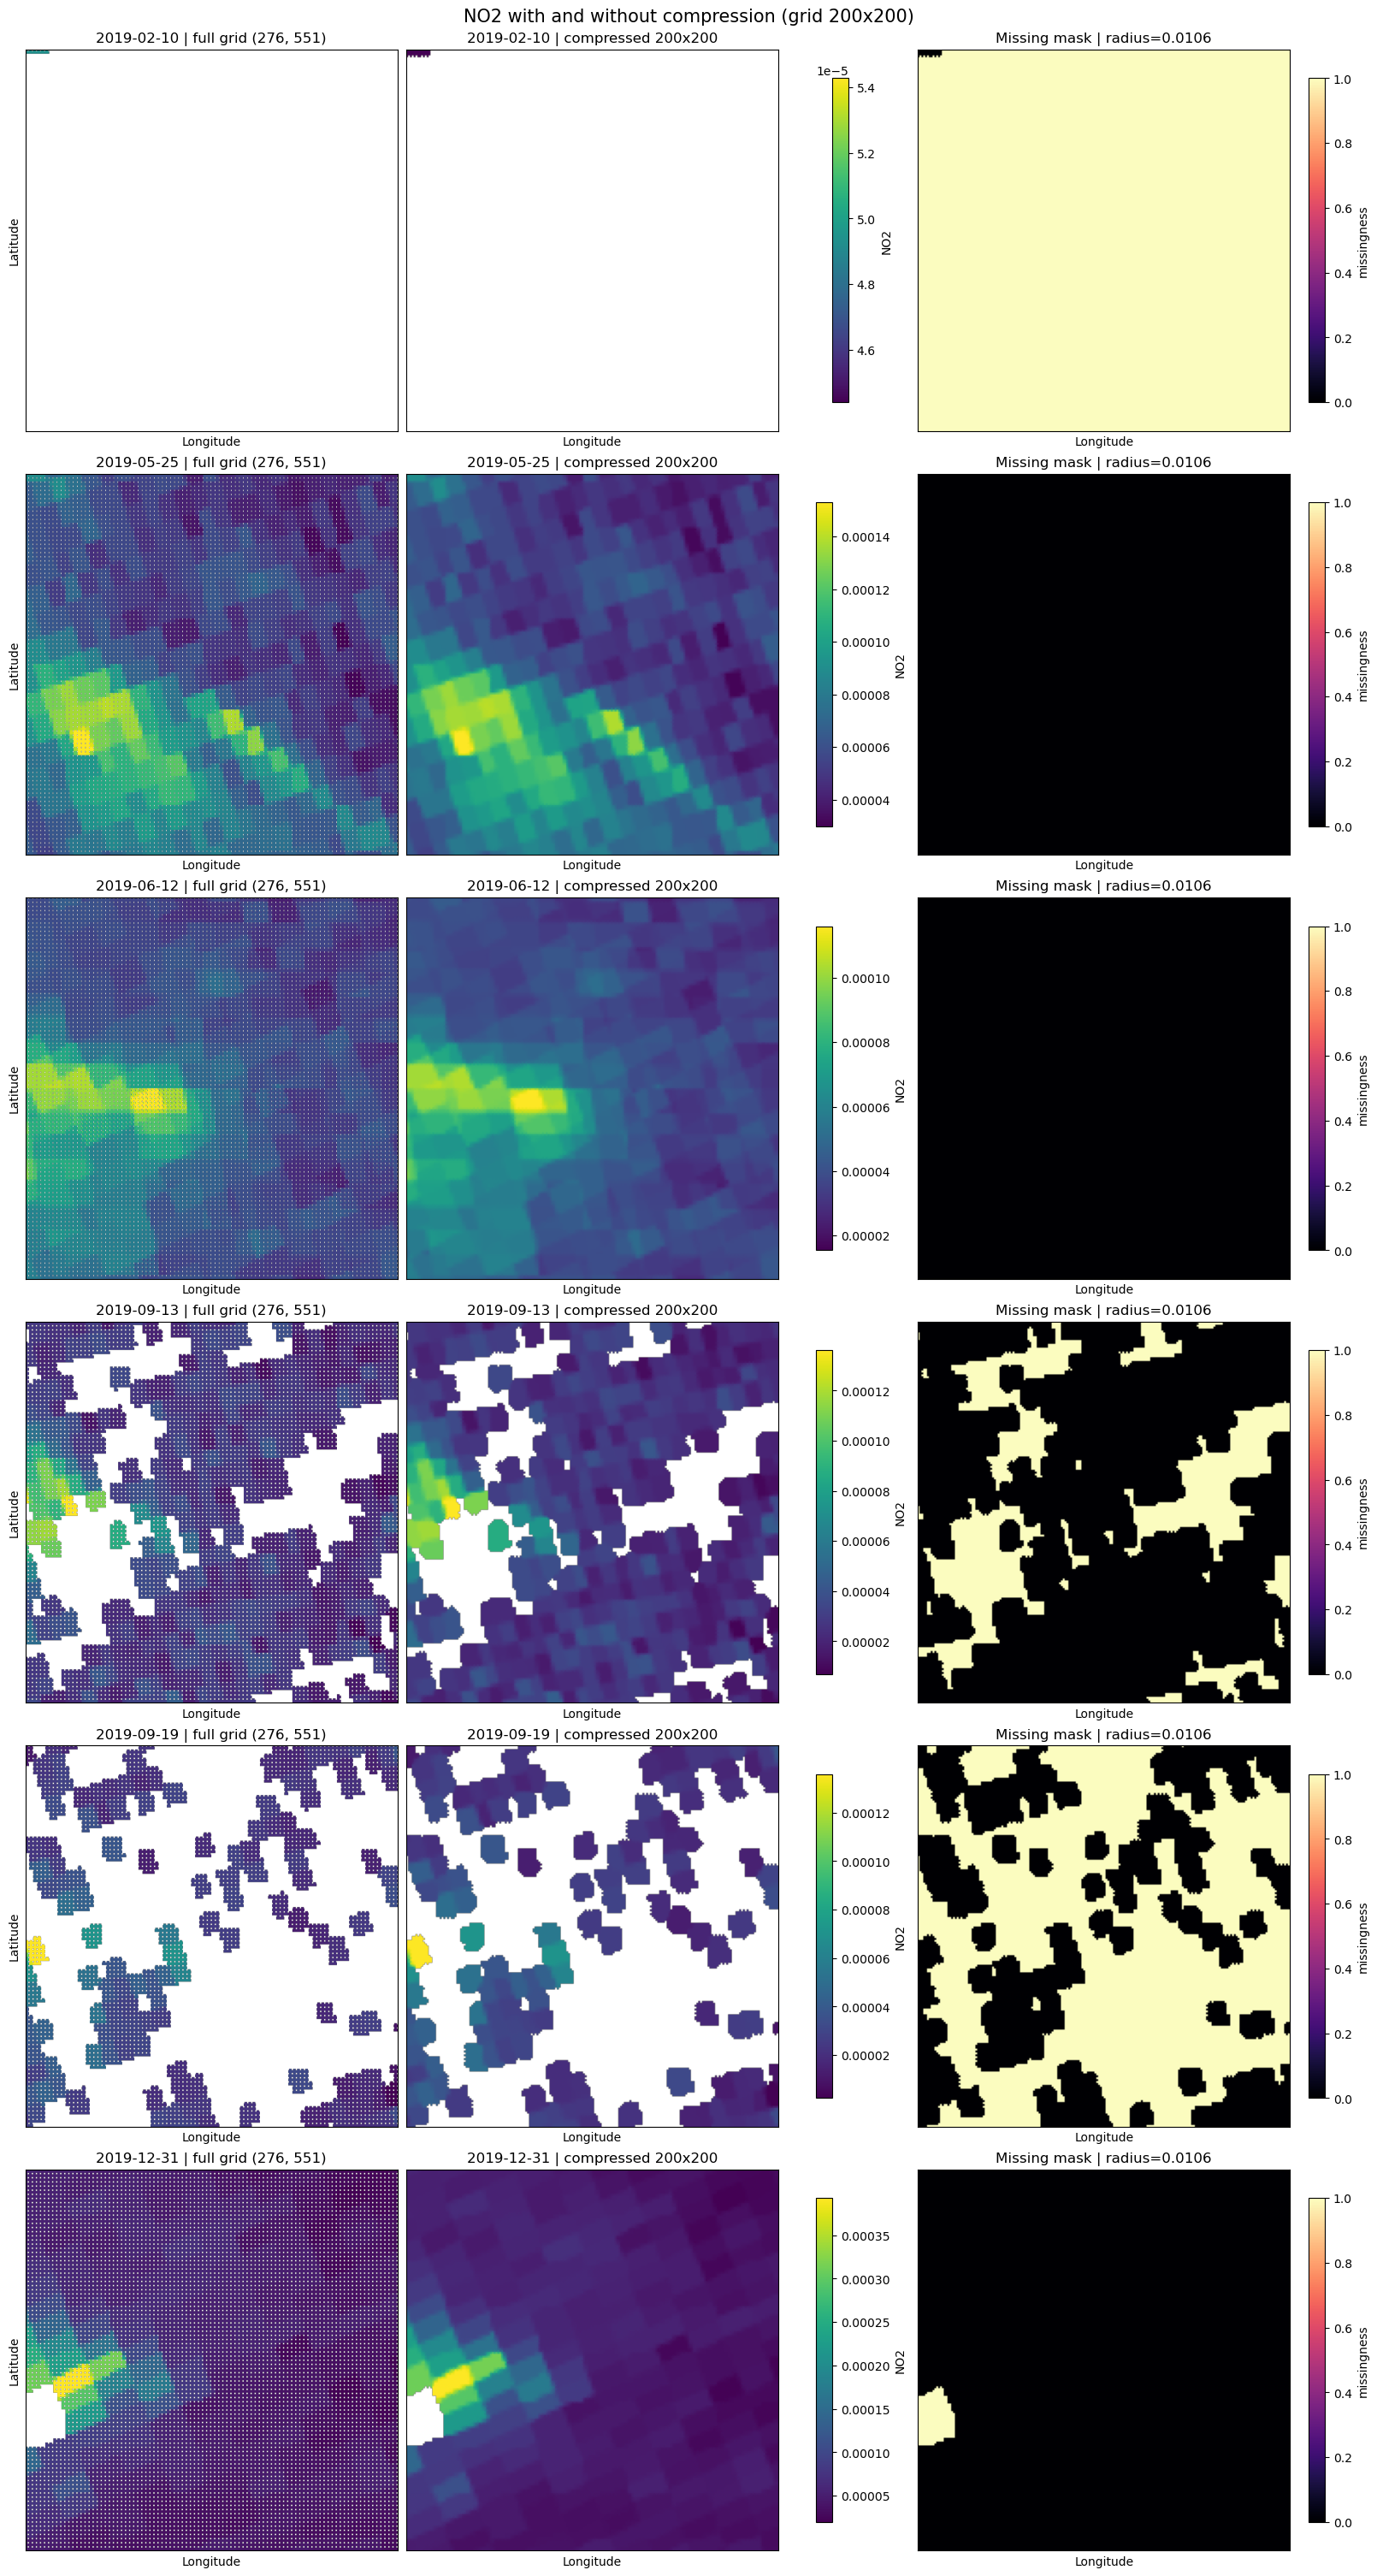

In [ ]:
def plot_compression_examples(no2_df, grid_shape=(100,100), n_days=2, value_col="NO2", radius_multiplier=1.5):
    """Plot the same day with and without spatial compression using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    day_counts = work_df.groupby("day").size().sort_values(ascending=False)
    if day_counts.empty:
        raise ValueError("No valid days found for plotting.")

    if n_days <= 1:
        sample_days = pd.to_datetime([day_counts.index[0]])
    elif n_days == 2:
        sample_days = pd.to_datetime([day_counts.index[0], day_counts.index[-1]])
    else:
        sample_days = pd.to_datetime(day_counts.iloc[np.linspace(0, len(day_counts) - 1, n_days, dtype=int)].index.sort_values())
    full_extent = [lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()]

    fig, axes = plt.subplots(len(sample_days), 3, figsize=(16, 5 * len(sample_days)), constrained_layout=True)
    if len(sample_days) == 1:
        axes = np.array([axes])

    for row_idx, day in enumerate(sample_days):
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", value_col]].dropna().copy()
        if day_df.empty:
            continue

        full_grid, full_mask, full_lat_axis, full_lon_axis, full_radius = build_radius_regular_grid(day_df, grid_shape=None, value_col=value_col, radius_multiplier=radius_multiplier)
        compressed_grid, compressed_mask, compressed_lat_axis, compressed_lon_axis, compressed_radius = build_radius_regular_grid(day_df, grid_shape=grid_shape, value_col=value_col, radius_multiplier=radius_multiplier)

        shared_vmin = np.nanmin([np.nanmin(full_grid), np.nanmin(compressed_grid)])
        shared_vmax = np.nanmax([np.nanmax(full_grid), np.nanmax(compressed_grid)])

        ax0, ax1, ax2 = axes[row_idx]
        im0 = ax0.imshow(full_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=full_extent)
        ax0.set_title(f"{day.date()} | full grid {full_grid.shape}")
        ax0.set_xlabel("Longitude")
        ax0.set_ylabel("Latitude")

        compressed_extent = [compressed_lon_axis.min(), compressed_lon_axis.max(), compressed_lat_axis.min(), compressed_lat_axis.max()]
        im1 = ax1.imshow(compressed_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=compressed_extent)
        ax1.set_title(f"{day.date()} | compressed {grid_shape[0]}x{grid_shape[1]}")
        ax1.set_xlabel("Longitude")

        missing_mask = 1 - compressed_mask
        im2 = ax2.imshow(missing_mask, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1, extent=compressed_extent)
        ax2.set_title(f"Missing mask | radius={compressed_radius:.4f}")
        ax2.set_xlabel("Longitude")

        for ax in (ax0, ax1, ax2):
            ax.set_yticks([])
            ax.set_xticks([])

        fig.colorbar(im0, ax=[ax0, ax1], shrink=0.85, label=value_col)
        fig.colorbar(im2, ax=ax2, shrink=0.85, label="missingness")

    fig.suptitle(f"NO2 with and without compression (grid {grid_shape[0]}x{grid_shape[1]})", fontsize=15)
    plt.show()


plot_compression_examples(no2, grid_shape=(200,200), n_days=6, value_col="NO2", radius_multiplier=1.5)

In [ ]:
def create_regularized_no2_dataset(no2_df, grid_shape=(100,100), value_col="NO2", min_points=20, radius_multiplier=1.5):
    """Create one compressed regular-grid NO2 frame per day using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    if work_df.empty:
        raise ValueError("no2_df has no valid timestamp/latitude/longitude/value rows.")

    records = []
    grid_stack = []
    mask_stack = []
    day_groups = work_df.groupby("day", sort=True)

    for day, day_df in day_groups:
        if len(day_df) < min_points:
            continue

        compressed_grid, compressed_mask, lat_axis, lon_axis, radius = build_radius_regular_grid(
            day_df,
            grid_shape=grid_shape,
            value_col=value_col,
            radius_multiplier=radius_multiplier,
        )

        grid_stack.append(compressed_grid.astype(np.float32))
        mask_stack.append(compressed_mask.astype(np.uint8))
        records.append({
            "datetime": day,
            "n_observations": len(day_df),
            "grid": compressed_grid.astype(np.float32),
            "mask": compressed_mask.astype(np.uint8),
            "coverage_fraction": float(compressed_mask.mean()),
        })

    if not records:
        raise ValueError("No days had enough points to build a compressed dataset.")

    regularized_df = pd.DataFrame(records)
    grid_tensor = np.stack(grid_stack, axis=0)
    mask_tensor = np.stack(mask_stack, axis=0)

    return regularized_df, grid_tensor, mask_tensor, lat_axis, lon_axis


chosen_grid_shape = (100,100)
regularized_no2_df, regularized_no2_tensor, regularized_no2_mask_tensor, compressed_lat_axis, compressed_lon_axis = create_regularized_no2_dataset(
    no2,
    grid_shape=chosen_grid_shape,
    value_col="NO2",
    min_points=20,
    radius_multiplier=1.5,
)

print(f"Created compressed NO2 dataset with {len(regularized_no2_df):,} days.")
print(f"Grid tensor shape: {regularized_no2_tensor.shape}  (days, rows, cols)")
print(f"Mask tensor shape: {regularized_no2_mask_tensor.shape}")
print(f"Latitude axis length: {len(compressed_lat_axis)}")
print(f"Longitude axis length: {len(compressed_lon_axis)}")
print(regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].head())

np.savez_compressed(
    "./data/no2_regularized_100x100.npz",
    datetime=regularized_no2_df["datetime"].dt.strftime("%Y-%m-%d").to_numpy(),
    n_observations=regularized_no2_df["n_observations"].to_numpy(),
    coverage_fraction=regularized_no2_df["coverage_fraction"].to_numpy(),
    grids=regularized_no2_tensor,
    masks=regularized_no2_mask_tensor,
    lat_axis=compressed_lat_axis,
    lon_axis=compressed_lon_axis,
    grid_shape=np.array(chosen_grid_shape, dtype=np.int32),
)

# regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].to_csv("./data/no2_regularized_100x100_metadata.csv", index=False)

regularized_no2_df.head()


Created compressed NO2 dataset with 338 days.
Grid tensor shape: (338, 100, 100)  (days, rows, cols)
Mask tensor shape: (338, 100, 100)
Latitude axis length: 100
Longitude axis length: 100
    datetime  n_observations  coverage_fraction
0 2019-01-01            8464             1.0000
1 2019-01-02            4479             0.5749
2 2019-01-03           13007             0.9713
3 2019-01-05            8464             1.0000
4 2019-01-06            4452             0.5982


,datetime,n_observations,grid,mask,coverage_fraction
0,2019-01-01,8464,"[[0.000102101694, 8.558364e-05, 7.44714e-05, 6...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.0000
1,2019-01-02,4479,"[[4.2139814e-05, 3.654661e-05, 3.613784e-05, 3...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.5749
2,2019-01-03,13007,"[[5.6902794e-05, 6.243599e-05, 6.2603074e-05, ...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.9713
3,2019-01-05,8464,"[[5.1588722e-05, 5.4509193e-05, 5.6152177e-05,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.0000
4,2019-01-06,4452,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0.5982
